In [1]:
# Append path to deconversation modules
import sys
import os
import scanpy as sc
sys.path.append('../../deconversation')

In [2]:
# Import associated modules
from pseudobulk import *
from preprocessing import *

In [5]:
from embeddings import *
from deconvolution import *
from visualization import *

geneformer successfully imported.
cell2sentence is not installed. Skipping related functions.
cellhermes is not installed. Skipping related functions.
scGPT is not installed. Skipping related functions.
scVI successfully imported.


In [6]:
# Path to single-cell RNAseq data 
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/geneformer/complete/haoSub.h5ad"

In [7]:
# Read the h5ad file (just to explore columns and variables)
adata = sc.read_h5ad(path)

adata = adata[adata.obs["broad_type"].isin(
    ['B cells', 'Monocytes', 'NK cells', 'T cells', 'mDC', 'pDC']
)]

# Remove unmapped genes
#adata.var.index = adata.var.gene_name
adata = adata[:, adata.var.index.notnull()]

# Prep data for geneformer
adata = load_and_prep_data(adata= adata, cell_type_col= "broad_type", mode="geneformer")

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/preprocessing.py:50: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["cell_id"] = adata.obs.index


In [8]:
adata.obs["broad_type"].value_counts()

broad_type
T cells      61766
Monocytes    48439
NK cells     18005
B cells      13371
mDC           2361
pDC            849
Name: count, dtype: int64

In [9]:
# Read in bulk RNAseq data
hoek_bulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_counts.csv",
                       index_col=0)

# Map genes to ensembl id (required for geneformer)
hoek_bulk.index = gene_id_name_map(gene_list=hoek_bulk.index, mode="to_ensembl" )

# Drop unmapped genes 
hoek_bulk = hoek_bulk.loc[hoek_bulk.index.dropna()]

In [ ]:
sig_mat = create_signature_matrix(adata = adata,
                                     sample_col = "batch", # sample id column
                                     cell_type_col = "broad_type",
                                     groupby = "broad_type",
                                     output_path = None)

# Transpose for embedding extraction
sig_mat = sig_mat.T

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/preprocessing.py:256: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signature = expr.groupby(groupby).mean().T


In [ ]:
ground_truth = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/deconvBench/bulk/hoek/hoek_facs.csv",
                          index_col=0)

ground_truth = ground_truth.T

In [ ]:
def harmonize_columns(df):
    df = df.copy()
    # Merge pDC into mDC (only if both present)
    if "pDC" in df.columns and "mDC" in df.columns:
        df["mDC"] = df["mDC"] + df["pDC"]
        df = df.drop(columns=["pDC"])
    elif "pDC" in df.columns:            # pDC alone -> treat as mDC
        df = df.rename(columns={"pDC": "mDC"})
    # Rename T cells -> T cell
    df = df.rename(columns={"T cells": "T cell"})
    return df

In [ ]:
sig_mat.head()

In [ ]:
hoek_bulk.T.head()

## Zero-Shot 

In [16]:
layer_results = {}
metric_rows = []
celltype_rows = []

for layer in range(17, 19):
    print(f"=== layer {layer} ===", flush=True)

    sig_mat_gf_embed = extract_embs(
        bulk_df=sig_mat,
        mode="geneformer",
        temp_output_dir="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/",
        model_path="ctheodoris/Geneformer",
        delete_temp_files=True,
        layer_to_quant=layer,
    )

    gf_embed = extract_embs(
        bulk_df=hoek_bulk.T,
        mode="geneformer",
        temp_output_dir="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/",
        model_path="ctheodoris/Geneformer",
        delete_temp_files=True,
        layer_to_quant=layer,
    )

    results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
    results = {solver: harmonize_columns(df) for solver, df in results.items()}

    layer_results[layer] = results
    
    # score each solver against ground truth
    for solver, df in results.items():
        samples = df.index.intersection(ground_truth.index)
        celltypes = df.columns.intersection(ground_truth.columns)
    
        P = df.loc[samples, celltypes].astype(float)
        T = ground_truth.loc[samples, celltypes].astype(float)
    
        # --- overall (flattened across all samples x celltypes) ---
        p = P.values.ravel()
        t = T.values.ravel()
        ok = np.isfinite(p) & np.isfinite(t)
    
        # --- per celltype ---
        for ct in celltypes:
            a = P[ct].values
            b = T[ct].values
            m = np.isfinite(a) & np.isfinite(b)
    
            # correlation is undefined if either vector is constant
            if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
                r_ct = np.corrcoef(a[m], b[m])[0, 1]
            else:
                r_ct = np.nan
    
            celltype_rows.append({
                "layer": layer,
                "solver": solver,
                "celltype": ct,
                "correlation": r_ct,
                "rmse": np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan,
            })
    
        # mean across celltypes for this layer/solver
        ct_sub = [r for r in celltype_rows if r["layer"] == layer and r["solver"] == solver]
        corrs = np.array([r["correlation"] for r in ct_sub], dtype=float)
        mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
        mean_rmse = np.nanmean([r["rmse"] for r in ct_sub])
    
        metric_rows.append({
            "layer": layer,
            "solver": solver,
            "correlation": np.corrcoef(p[ok], t[ok])[0, 1],
            "rmse": np.sqrt(np.mean((p[ok] - t[ok]) ** 2)),
            "meanCorrelation": mean_corr,
            "meanRMSE": mean_rmse,
        })

metrics_df  = pd.DataFrame(metric_rows)
celltype_df = pd.DataFrame(celltype_rows)

metrics_df.to_csv("../../results/gf_layer_sweep/layer_sweep_metrics_zeroshot_hoek.csv", index=False)

=== layer 1 ===
Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 27.66it/s]

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.



/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:740: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['B cells', 'Monocytes', 'NK cells', 'T cells', 'mDC']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be t

Loading Geneformer model...


...

Loading Geneformer model...
Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

Condition number: 11.51.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.2006.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.9558.
Most similar pair: NK cells vs T cells.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.00 seconds.
Running solver: nnls_mod
Finished in 0.00 seconds.
Running solver: dwls
Finished in 0.01 seconds.
Running solver: simplex
Finished in 0.01 seconds.
Running solver: ridge_simplex
Finished in 0.01 seconds.
Running solver: dwls_simplex
Finished in 0.01 seconds.
Running solver: ridge
Finished in 0.01 seconds.
Running solver: elasticnet
Finished in 0.00 seconds.
Running solver: nusvr
Finished in 0.18 seconds.
Running solver: simplex_nnls
Finished in 0.00 seconds.
Running solver: gradient_de

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  references = torch.tensor(references, dtype=torch.float32)
/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mixture = torch.tensor(mixture, dtype=torch.float32)


Finished in 0.25 seconds.


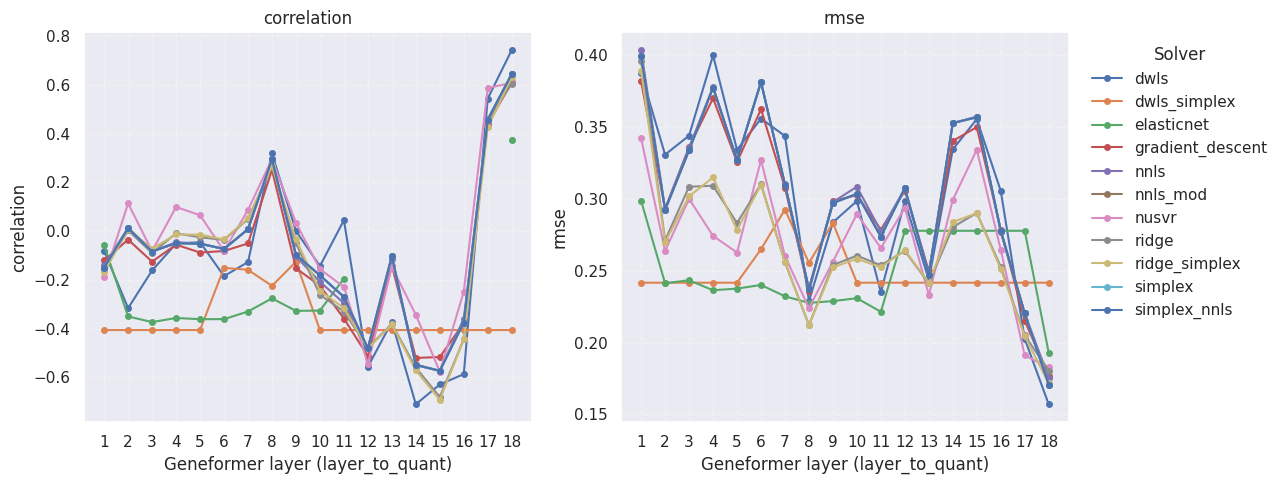

     layer            solver  correlation      rmse  meanCorrelation  meanRMSE
189     18              dwls     0.742730  0.157023         0.628504  0.116155
93       9      dwls_simplex    -0.125702  0.283276         0.324517  0.245107
194     18        elasticnet     0.373308  0.192985         0.689092  0.159537
197     18  gradient_descent     0.610337  0.176918         0.609415  0.132741
187     18              nnls     0.643422  0.175443         0.583314  0.131050
188     18          nnls_mod     0.644625  0.170658         0.575124  0.129988
195     18             nusvr     0.608123  0.182691         0.451008  0.144466
193     18             ridge     0.604839  0.180432         0.591390  0.136332
191     18     ridge_simplex     0.631665  0.171665         0.518383  0.131480
190     18           simplex     0.644626  0.170657         0.585134  0.129988
196     18      simplex_nnls     0.644626  0.170657         0.403722  0.129988


In [17]:
# --- visualize ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ["correlation", "rmse"]):
    for solver, sub in metrics_df.groupby("solver"):
        sub = sub.sort_values("layer")
        ax.plot(sub["layer"], sub[metric], marker="o", markersize=4, label=solver)
    ax.set_xlabel("Geneformer layer (layer_to_quant)")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle="--")

axes[1].legend(title="Solver", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig("../../results/gf_layer_sweep/layer_sweep_zeroshot_hoek.png", dpi=300, bbox_inches="tight")
plt.show()

# best layer per solver
print(metrics_df.loc[metrics_df.groupby("solver")["correlation"].idxmax()])

# inspect any single layer with your existing plot
#visualize_solvers(layer_results[12], ground_truth, level=["global"])

## Fine-tuned

In [18]:
layer_results = {}
metric_rows = []
celltype_rows = []

for layer in range(1, 19):
    print(f"=== layer {layer} ===", flush=True)

    sig_mat_gf_embed = extract_embs(
        bulk_df=sig_mat,
        mode="geneformer",
        temp_output_dir="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/",
        model_path="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/260624_geneformer_cellClassifier_gf_finetune/ksplit1/",
        delete_temp_files=True,
        layer_to_quant=layer,
    )

    gf_embed = extract_embs(
        bulk_df=hoek_bulk.T,
        mode="geneformer",
        temp_output_dir="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/",
        model_path="/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/260624_geneformer_cellClassifier_gf_finetune/ksplit1/",
        delete_temp_files=True,
        layer_to_quant=layer,
    )

    results = run_all_deconv(bulk_df=gf_embed.T, signature_df=sig_mat_gf_embed.T)
    results = {solver: harmonize_columns(df) for solver, df in results.items()}

    layer_results[layer] = results
    
    # score each solver against ground truth
    for solver, df in results.items():
        samples = df.index.intersection(ground_truth.index)
        celltypes = df.columns.intersection(ground_truth.columns)
    
        P = df.loc[samples, celltypes].astype(float)
        T = ground_truth.loc[samples, celltypes].astype(float)
    
        # --- overall (flattened across all samples x celltypes) ---
        p = P.values.ravel()
        t = T.values.ravel()
        ok = np.isfinite(p) & np.isfinite(t)
    
        # --- per celltype ---
        for ct in celltypes:
            a = P[ct].values
            b = T[ct].values
            m = np.isfinite(a) & np.isfinite(b)
    
            # correlation is undefined if either vector is constant
            if m.sum() > 1 and np.std(a[m]) > 0 and np.std(b[m]) > 0:
                r_ct = np.corrcoef(a[m], b[m])[0, 1]
            else:
                r_ct = np.nan
    
            celltype_rows.append({
                "layer": layer,
                "solver": solver,
                "celltype": ct,
                "correlation": r_ct,
                "rmse": np.sqrt(np.mean((a[m] - b[m]) ** 2)) if m.sum() else np.nan,
            })
    
        # mean across celltypes for this layer/solver
        ct_sub = [r for r in celltype_rows if r["layer"] == layer and r["solver"] == solver]
        corrs = np.array([r["correlation"] for r in ct_sub], dtype=float)
        mean_corr = np.mean(np.nan_to_num(corrs, nan=0.0))
        mean_rmse = np.nanmean([r["rmse"] for r in ct_sub])
    
        metric_rows.append({
            "layer": layer,
            "solver": solver,
            "correlation": np.corrcoef(p[ok], t[ok])[0, 1],
            "rmse": np.sqrt(np.mean((p[ok] - t[ok]) ** 2)),
            "meanCorrelation": mean_corr,
            "meanRMSE": mean_rmse,
        })

metrics_df  = pd.DataFrame(metric_rows)
celltype_df = pd.DataFrame(celltype_rows)

metrics_df.to_csv("../../results/gf_layer_sweep/layer_sweep_metrics_finetuned_hoek.csv", index=False)

=== layer 1 ===
Pseudobulk AnnData saved to: /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad
Starting Geneformer tokenization...
Tokenizing /gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 28.04it/s]

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv_data/DECONVersation/temp/gf_tokens.h5ad has no column attribute 'filter_pass'; tokenizing all cells.
Creating dataset.



/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:740: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['B cells', 'Monocytes', 'NK cells', 'T cells', 'mDC']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:787: ImplicitModificationWarning: Trying to modify index of attribute `.obs` of view, initializing view as actual.
  getattr(self, attr).index = value
/nfs/home/aoku/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/gpfs/commons/groups/compbio/projects/rf_condas/deconv_gf_test/lib/python3.10/site-packages/geneformer/tokenizer.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be t

Loading Geneformer model...


...

Loading tokenized dataset...
Extracting Geneformer embeddings...


  0%|          | 0/1 [00:00<?, ?it/s]

Condition number: 5.38.
~1-10: signatures are well separated; NNLS is usually hard to improve materially with another solver.
Smallest singular value: 0.3754.
If value is close to zero, the signature matrix is ill-conditioned; estimated proportions may be unstable.
Max pairwise cosine similarity between cell types: 0.8419.
Most similar pair: Monocytes vs mDC.
If value is close to 1, these cell types are highly similar and difficult to resolve separately.
Running solver: nnls
Finished in 0.00 seconds.
Running solver: nnls_mod
Finished in 0.00 seconds.
Running solver: dwls
Finished in 0.01 seconds.
Running solver: simplex
Finished in 0.01 seconds.
Running solver: ridge_simplex
Finished in 0.01 seconds.
Running solver: dwls_simplex
Finished in 0.02 seconds.
Running solver: ridge
Finished in 0.01 seconds.
Running solver: elasticnet
Finished in 0.00 seconds.
Running solver: nusvr
Finished in 0.20 seconds.
Running solver: simplex_nnls
Finished in 0.01 seconds.
Running solver: gradient_descen

/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  references = torch.tensor(references, dtype=torch.float32)
/gpfs/commons/groups/compbio/projects/ao_projects/ml_deconv/tutorials/GF_layer_sweep/../../deconversation/deconvolution.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mixture = torch.tensor(mixture, dtype=torch.float32)


Finished in 0.25 seconds.


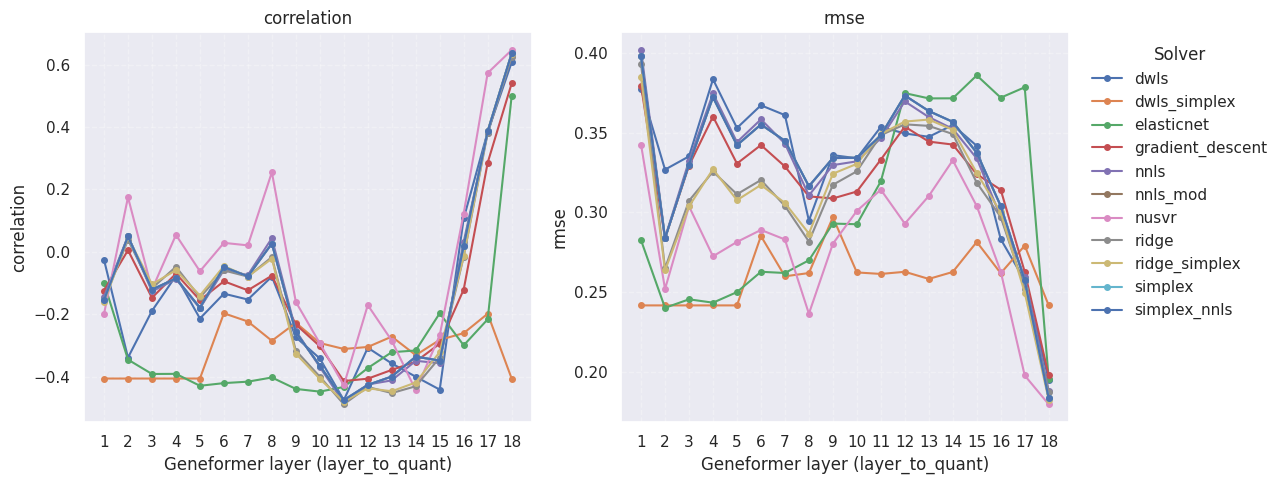

     layer            solver  correlation      rmse  meanCorrelation  meanRMSE
189     18              dwls     0.607353  0.195002         0.385151  0.154746
60       6      dwls_simplex    -0.196780  0.285157         0.136098  0.245151
194     18        elasticnet     0.499408  0.195378         0.553160  0.168709
197     18  gradient_descent     0.539867  0.197634         0.554475  0.157361
187     18              nnls     0.627156  0.188040         0.479624  0.149906
188     18          nnls_mod     0.635890  0.183270         0.504019  0.147775
195     18             nusvr     0.646769  0.179529         0.562202  0.143928
193     18             ridge     0.625562  0.187468         0.488231  0.150548
191     18     ridge_simplex     0.635107  0.182413         0.417940  0.147826
190     18           simplex     0.635892  0.183269         0.464227  0.147774
196     18      simplex_nnls     0.635892  0.183269         0.393454  0.147774


In [19]:
# --- visualize ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric in zip(axes, ["correlation", "rmse"]):
    for solver, sub in metrics_df.groupby("solver"):
        sub = sub.sort_values("layer")
        ax.plot(sub["layer"], sub[metric], marker="o", markersize=4, label=solver)
    ax.set_xlabel("Geneformer layer (layer_to_quant)")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(range(1, 19))
    ax.grid(alpha=0.3, linestyle="--")

axes[1].legend(title="Solver", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
fig.savefig("../../results/gf_layer_sweep/layer_sweep_finetuned_hoek.png", dpi=300, bbox_inches="tight")
plt.show()

# best layer per solver
print(metrics_df.loc[metrics_df.groupby("solver")["correlation"].idxmax()])

# inspect any single layer with your existing plot
#visualize_solvers(layer_results[12], ground_truth, level=["global"])